# Inspect hemoglobin in three dimensions

Rotate real 1A3N coordinates, inspect heme and its neighbors, and connect chain numbering to a RefSeq protein sequence.

**Bioinformatics · Lesson 06 · 60 minutes · Embedded real data · Offline core analysis**

## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the biological question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
RECIPE_ID='06-hemoglobin-structure'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'structure': '86cdd64dd8465a5f1448470db5067ea1ebccc2b61faad19710f78e9714d56e29', 'sequences': 'a8ae02a43c841e2932efafaf82a0bf78199baa8921a821fcbd774c8d7649e8b7'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['structure', 'sequences']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def parse_pdb(text):
    """First model; choose highest occupancy altloc, then blank/A/lexical order."""
    rows, first_model, inside = {}, None, True
    for line in text.splitlines():
        record = line[:6].strip()
        if record == "MODEL":
            number = line[10:14].strip()
            if first_model is None:
                first_model = number
            inside = number == first_model
        if record == "ENDMDL" and inside:
            break
        if record not in ("ATOM","HETATM") or not inside:
            continue
        try:
            atom = dict(record=record,serial=int(line[6:11]),atom=line[12:16].strip(),altloc=line[16:17].strip(),
                residue=line[17:20].strip(),chain=line[21:22].strip(),resnum=int(line[22:26]),icode=line[26:27].strip(),
                x=float(line[30:38]),y=float(line[38:46]),z=float(line[46:54]),
                occupancy=float(line[54:60].strip() or 0),bfactor=float(line[60:66].strip() or 0),element=line[76:78].strip())
        except ValueError as exc:
            raise ValueError("Invalid PDB numeric fields") from exc
        key = (record,atom["chain"],atom["resnum"],atom["icode"],atom["residue"],atom["atom"])
        rank = (atom["occupancy"],atom["altloc"]=="",atom["altloc"]=="A")
        old = rows.get(key)
        if old is None or rank > old[0] or (rank == old[0] and atom["altloc"] < old[1]["altloc"]):
            rows[key] = (rank,atom)
    columns = ["record","serial","atom","altloc","residue","chain","resnum","icode","x","y","z","occupancy","bfactor","element"]
    atoms = pd.DataFrame([entry[1] for entry in rows.values()],columns=columns)
    if atoms.empty:
        raise ValueError("No atoms in the first model")
    if not np.isfinite(atoms[["x","y","z","occupancy"]].to_numpy()).all():
        raise ValueError("Nonfinite coordinates or occupancy")
    return atoms

print("Method ready: parse_pdb")


Method ready: parse_pdb


## Steps

### 1. Read structure metadata before viewing the model

1A3N is an experimental X-ray structure of human deoxyhemoglobin. The model contains alpha and beta protein chains and heme ligands. Resolution describes the experiment, not a uniform atom-position error bar. Inspect experimental method, resolution and accession before rotating a convincing-looking picture. No structure prediction runs in this lesson.

In [4]:
structure=snapshot("structure")
pdb_text=structure["pdb"];entry=structure["entry"]
print("PDB:",structure["pdb_id"])
print("Method:",[item["method"] for item in entry["exptl"]])
print("Resolution (Å):",entry["rcsb_entry_info"].get("resolution_combined"))
print("Title:",entry["struct"]["title"])
print("Coordinate file:",len(pdb_text),"characters")


PDB: 1A3N
Method: ['X-RAY DIFFRACTION']
Resolution (Å): [1.8]
Title: DEOXY HUMAN HEMOGLOBIN
Coordinate file: 461700 characters


### 2. Parse chains, insertion codes and alternate conformations

Our small parser reads fixed PDB columns for ATOM/HETATM records. It selects the first model and one alternative per atom by occupancy, with deterministic tie-breaking. Residue identity includes chain, residue number and insertion code. Keep occupancy-zero atoms in the audit, then exclude them from coordinate-based analyses. The parser is for this documented format; arbitrary mmCIF files require a different parser.

In [5]:
atoms=parse_pdb(pdb_text)
usable=atoms.loc[atoms.occupancy>0].copy()
protein=usable.loc[usable.record=="ATOM"]
ca=protein.loc[protein.atom=="CA"].sort_values(["chain","resnum","icode"])
chain_summary=ca.groupby("chain").agg(observed_ca=("atom","size"),first_residue=("resnum","min"),last_residue=("resnum","max"))
display(chain_summary)
display(usable.loc[usable.record=="HETATM"].groupby("residue").size().rename("atoms").to_frame())
print("Parsed atoms:",len(atoms),"; zero occupancy:",int((atoms.occupancy==0).sum()))


,observed_ca,first_residue,last_residue
chain,,,
A,141,1,141
B,145,2,146
C,141,1,141
D,145,2,146


,atoms
residue,
HEM,172
HOH,451


Parsed atoms: 4993 ; zero occupancy: 37


### 3. Rotate the model and inspect heme

The viewer uses the embedded coordinate text and the app's bundled 3Dmol library. Drag to rotate and pinch to zoom. Cartoon follows the protein backbone; sticks highlight heme. Water is hidden to reduce clutter. Change STYLE between `cartoon` and `stick` (the API key is singular) and rerun the cell. Labels and color choices aid inspection; they are not experimental evidence.

In [6]:
import py3Dmol
STYLE="cartoon"
view=py3Dmol.view(width="100%",height=420)
view.addModel(pdb_text,"pdb")
view.setStyle({"hetflag":False},{STYLE:{"colorscheme":"chain"}})
view.setStyle({"resn":"HEM"},{"stick":{"colorscheme":"orangeCarbon","radius":.18}})
view.setStyle({"resn":"HOH"},{})
view.setBackgroundColor("#f8faf8");view.zoomTo()
display(HTML(view._make_html()))
print("Interactive 1A3N view: drag to rotate; pinch/scroll to zoom")


Interactive 1A3N view: drag to rotate; pinch/scroll to zoom


### 4. Project the observed backbone into coordinates

This static view uses one Cα atom per observed residue, colored by chain. It remains readable without WebGL and provides a coordinate-level companion to the interactive viewer. Lines connect sequential observed residues only when consecutive residue numbers have no gap; a missing residue must not be bridged as if it were observed.

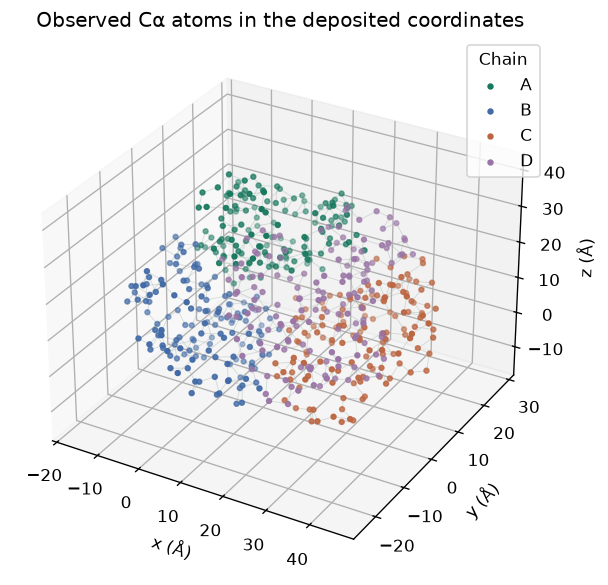

In [7]:
fig=plt.figure(figsize=(7,5));ax=fig.add_subplot(111,projection="3d")
for chain,rows in ca.groupby("chain"):
    coords=rows[["x","y","z"]].to_numpy();ax.scatter(*coords.T,s=8,label=chain)
    numbers=rows.resnum.to_numpy()
    for i in range(len(rows)-1):
        if numbers[i+1]-numbers[i]==1:ax.plot(*coords[i:i+2].T,color="#afbdb5",lw=.5,alpha=.5)
ax.set(xlabel="x (Å)",ylabel="y (Å)",zlabel="z (Å)",title="Observed Cα atoms in the deposited coordinates")
ax.legend(title="Chain");plt.tight_layout();plt.show()


### 5. Connect sequence numbering to the observed chain

RefSeq HBB translates to a 147-aa sequence including initiating methionine. The mature beta chain convention omits that methionine. Use the deposited SEQRES record for the expected chain sequence, then compare it with ATOM residues. Missing coordinates do not mean a residue is absent from the protein. This distinction matters when mapping a variant to a structure.

In [8]:
seqres={}
for line in pdb_text.splitlines():
    if line.startswith("SEQRES"):
        seqres.setdefault(line[11],[]).extend(line[19:70].split())
hbb=next(r for r in snapshot("sequences")["records"] if r["gene"]=="HBB")
print("RefSeq HBB amino acids:",len(hbb["translation"]),"; without starting methionine:",len(hbb["translation"][1:]))
for chain,rows in ca.groupby("chain"):
    expected=len(seqres.get(chain,[]));observed=len(rows)
    print("Chain",chain,"SEQRES:",expected,"; usable Cα:",observed,"; difference:",expected-observed)
display(ca.loc[ca.chain=="B",["chain","resnum","icode","residue"]].head(10))


RefSeq HBB amino acids: 147 ; without starting methionine: 146
Chain A SEQRES: 141 ; usable Cα: 141 ; difference: 0
Chain B SEQRES: 146 ; usable Cα: 145 ; difference: 1
Chain C SEQRES: 141 ; usable Cα: 141 ; difference: 0
Chain D SEQRES: 146 ; usable Cα: 145 ; difference: 1


,chain,resnum,icode,residue
1070,B,2,,HIS
1080,B,3,,LEU
1088,B,4,,THR
1095,B,5,,PRO
1102,B,6,,GLU
1111,B,7,,GLU
1120,B,8,,LYS
1129,B,9,,SER
1135,B,10,,ALA
1140,B,11,,VAL


### 6. Measure distances and define a contact map

For chain B, Euclidean Cα distance is computed in ångströms. A contact is distance <8 Å, excluding self-pairs and residues within two sequence positions. The threshold and atom choice define a descriptive contact map. They are not a universal biochemical interaction definition. The diagonal of the distance matrix must be zero and the matrix symmetric.

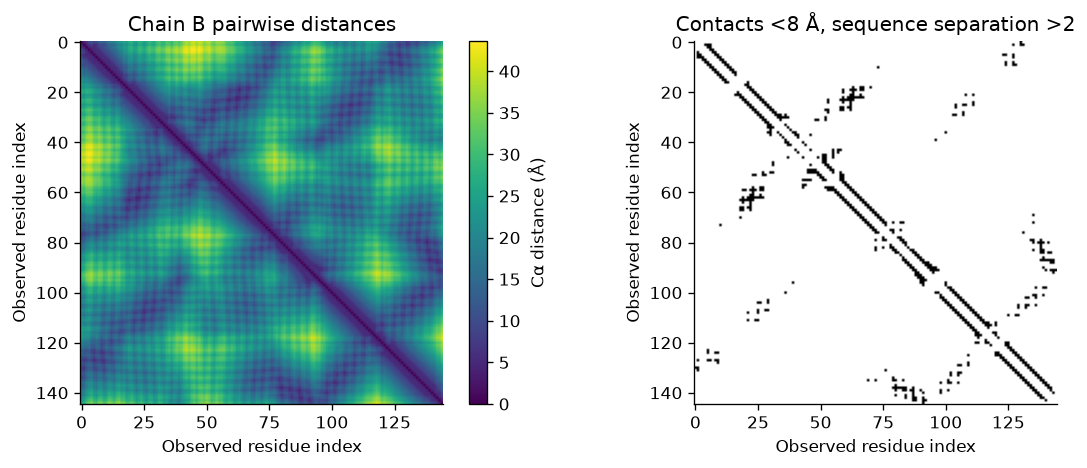

Unique contact pairs: 390


In [9]:
from scipy.spatial.distance import cdist
chain_b=ca.loc[ca.chain=="B"].copy()
xyz=chain_b[["x","y","z"]].to_numpy()
distances=cdist(xyz,xyz)
separation=np.abs(chain_b.resnum.to_numpy()[:,None]-chain_b.resnum.to_numpy()[None,:])
contacts=(distances<8)&(separation>2)
fig,axes=plt.subplots(1,2,figsize=(10,4))
im=axes[0].imshow(distances,cmap="viridis");fig.colorbar(im,ax=axes[0],label="Cα distance (Å)")
axes[1].imshow(contacts,cmap="Greys",vmin=0,vmax=1)
for ax,title in zip(axes,["Chain B pairwise distances","Contacts <8 Å, sequence separation >2"]):
    ax.set(xlabel="Observed residue index",ylabel="Observed residue index",title=title)
plt.tight_layout();plt.show()
assert np.allclose(distances,distances.T) and np.allclose(np.diag(distances),0)
print("Unique contact pairs:",int(np.triu(contacts,1).sum()))


### 7. Find residues near one heme ligand

Select chain B's heme and calculate each protein residue's minimum non-hydrogen atom distance to that ligand. Retain residues within 4 Å, including residues from another chain if they satisfy that condition. Proximity identifies inspection targets; it does not calculate affinity or prove catalysis. The B-factor plot describes model displacement parameters and must not be read as AlphaFold pLDDT.

,chain,resnum,icode,residue,minimum_distance_A
11,B,92,,HIS,2.261944
4,B,63,,HIS,3.296014
14,B,102,,ASN,3.387431
17,B,141,,LEU,3.414291
1,B,41,,PHE,3.479508
12,B,96,,LEU,3.519500
6,B,67,,VAL,3.526266
15,B,103,,PHE,3.589757
10,B,91,,LEU,3.707475
0,B,31,,LEU,3.744089


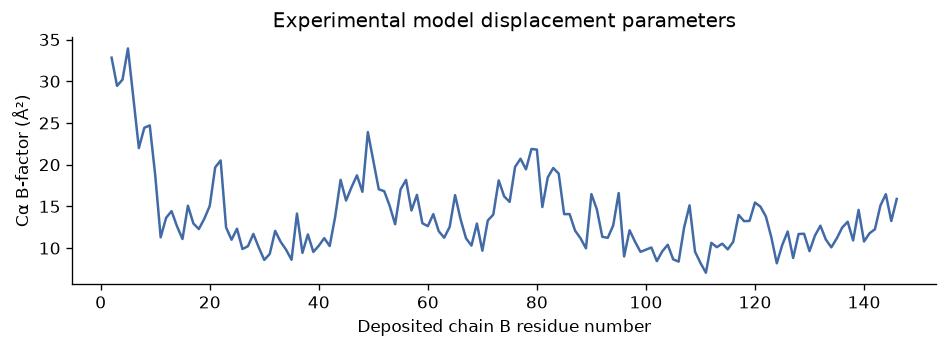

In [10]:
heavy=usable.loc[~usable.element.isin(["H","D"])]
heme=heavy.loc[(heavy.residue=="HEM")&(heavy.chain=="B")]
assert not heme.empty
near=[]
for key,rows in heavy.loc[heavy.record=="ATOM"].groupby(["chain","resnum","icode","residue"]):
    minimum=float(cdist(rows[["x","y","z"]],heme[["x","y","z"]]).min())
    if minimum<=4:near.append(dict(chain=key[0],resnum=key[1],icode=key[2],residue=key[3],minimum_distance_A=minimum))
neighbors=pd.DataFrame(near).sort_values("minimum_distance_A")
display(neighbors)
fig,ax=plt.subplots(figsize=(8,3))
ax.plot(chain_b.resnum,chain_b.bfactor,color="#416aa6")
ax.set(xlabel="Deposited chain B residue number",ylabel="Cα B-factor (Å²)",title="Experimental model displacement parameters")
plt.tight_layout();plt.show()


### 8. Export coordinates, tables and measurements

Keep the original coordinate file alongside the derived summary so another viewer can reproduce the scene. Label distance units and chain selection. The export contains observed atoms and residue identities; it does not fill missing residues or predict their coordinates.

In [11]:
assert set(ca.chain)=={"A","B","C","D"}
assert len(heme)>0 and len(chain_b)>100
assert np.isfinite(distances).all()
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
(OUTPUT_DIR/"1A3N.pdb").write_text(pdb_text)
chain_summary.to_csv(OUTPUT_DIR/"chains.csv")
neighbors.to_csv(OUTPUT_DIR/"heme-neighbors.csv",index=False)
pd.DataFrame(distances,index=chain_b.resnum,columns=chain_b.resnum).to_csv(OUTPUT_DIR/"chain-B-distances-A.csv")
atoms.to_csv(OUTPUT_DIR/"selected-first-model-atoms.csv",index=False)
print("Checks passed; original PDB and derived measurements exported")


Checks passed; original PDB and derived measurements exported


## Exercises and reference explanation

1. Why can SEQRES contain more residues than the usable ATOM Cα records?
2. Compare contact counts with 6, 8 and 10 Å cutoffs while keeping sequence separation >2.

**Reference explanation.** SEQRES describes the expected deposited polymer sequence; some atoms are unresolved or have zero occupancy. Increasing a fixed distance cutoff cannot remove contacts. Proximity still does not establish affinity.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Highlight the exported chain-B heme-neighbor residues in py3Dmol. Build selectors with chain, residue number and insertion code; use only the existing embedded PDB data.

**Prompt 2**

> Add a residue-label table for the contact map so every observed index resolves to chain/resnum/icode. Keep missing residues absent from the distance matrix.

**Human acceptance.** Check first-model selection, insertion-code identity, deterministic alternate selection, symmetric distances, zero diagonal and unchanged original PDB text. Never treat experimental B-factors as pLDDT.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [12]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://data.rcsb.org/rest/v1/core/entry/1A3N',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [RefSeq HBB/HBD](https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NM_000518.5%2CNM_000519.4&rettype=gb&retmode=xml) — NCBI public sequence data; retrieved 2026-10-09. SHA-256 `ea64e38e8e5ffad06f6d8770eaee066ef556e1488c4b9a6b340cbd445abe04ad`.
  GenBank XML CDS uses 1-based inclusive coordinates

- [PDB 1A3N coordinates](https://files.rcsb.org/download/1A3N.pdb) — CC0 1.0; retrieved 2026-10-09. SHA-256 `a4db006269e9b6f9db0eb5447a5d40e59d67857484a9294b9ca71d642ffe9861`.
  Original response preserved in the embedded snapshot.

- [RCSB 1A3N entry metadata](https://data.rcsb.org/rest/v1/core/entry/1A3N) — CC0 1.0; retrieved 2026-10-09. SHA-256 `e8fc0a94cd71b53bfa5736021ad877eaf68588632fb5be2c4f30040e340d11da`.
  Original response preserved in the embedded snapshot.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.